# Building Footprint Segmentation (Inria Aerial Image Labeling)
Dataset is already downloaded locally; this notebook does not download anything except (once) pretrained encoder weights.

**Goal:** for every pixel of an aerial photo, decide "building" or "not building".

### Design choices
| Decision | What I did | Why |
|---|---|---|
| Split | **Whole cities**, not tiles. Train = Austin + Chicago + Kitsap. Validation = Tyrol. Test = Vienna. | Tiles from the same city can share visual characteristics such as building styles and urban layouts. Splitting by city reduces spatial leakage and evaluates generalization to an unseen geographic region. |
| Model | U-Net decoder on top of a **ResNet34 encoder** | The dataset contains a limited number of large aerial tiles, so I use a ResNet34 encoder with ImageNet initialization to provide transferable visual features. The U-Net decoder and skip connections help recover spatial details needed for accurate building boundaries. If pretrained weights are unavailable, the notebook automatically uses random initialization. |
| Loss | BCE with edge weighting + Dice loss | Building pixels occupy a smaller portion of the image, so Dice loss helps address class imbalance. Additional weighting near boundaries encourages better building outline prediction. |
| Metrics | IoU, Dice/F1, precision, recall | Pixel accuracy can be misleading because background pixels dominate aerial images. Metrics are calculated from accumulated pixel-level counts across the evaluation set rather than averaging ratios from individual patches. |
| Reading the data | **Windowed reads** with `rasterio`: only the 512×512 window actually needed is pulled off disk. Full 5000×5000 tiles are never loaded into RAM. | The real dataset is about 20 GB; loading it all into memory is wasteful and can crash a shared server. |

### 2.1 Settings 

In [1]:
# EDIT THIS PATH before running on another machine
DATA_ROOT = "/scratch/muminul951/new/datasets/inria/AerialImageDataset"

# EDIT THIS: folder with the real contest test tiles once downloaded (no /gt/ here, no masks)
TEST_DATA_ROOT = "/scratch/muminul951/new/datasets/inria/AerialImageDataset/test/images"

PATCH = 512
BATCH_SIZE = 8

QUICK_RUN = False

if QUICK_RUN:
    PATCHES_PER_EPOCH = 64
    EPOCHS = 2
    VAL_PATCHES = 16
else:
    PATCHES_PER_EPOCH = 4000
    EPOCHS = 64
    VAL_PATCHES = 300

print(">>> QUICK RUN <<<" if QUICK_RUN else ">>> FULL RUN <<<")


>>> FULL RUN <<<


In [2]:
import os, glob, re, time, random, math, warnings, shutil
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "|", torch.cuda.get_device_name(0) if device.type == "cuda" else "no GPU found")
if device.type != "cuda" and not QUICK_RUN:
    raise RuntimeError("No GPU found. This is expected to run on the lab GPU server. (QUICK_RUN = True still works on CPU, for a quick check.)")


Device: cuda | NVIDIA RTX A6000


## Task 1 — Finding the tiles and checking image/mask alignment

The official `test/images` folder has no released masks, so it's useless for measuring accuracy.
That's why we build our own train/val split out of the 180 labelled tiles in `train/`, and save the
real predictions on the official test tiles at the very end for the contest submission.

In [3]:
# Check available tiles and verify image-mask pairs

image_files = sorted(glob.glob(f"{DATA_ROOT}/train/images/*.tif"))

if len(image_files) == 0:
    raise FileNotFoundError("No training images found. Check DATA_ROOT.")


CITY_RE = re.compile(r"^([a-z\-]+?)(\d+)$")

def city_and_number(path):
    name = os.path.splitext(os.path.basename(path))[0]
    match = CITY_RE.match(name)
    return (match.group(1), int(match.group(2))) if match else (None, None)


rows = []

for img_path in image_files:
    mask_path = img_path.replace("/images/", "/gt/")
    city, num = city_and_number(img_path)

    has_mask = os.path.exists(mask_path)
    same_size = False

    if has_mask:
        with rasterio.open(img_path) as img, rasterio.open(mask_path) as mask:
            same_size = (img.width, img.height) == (mask.width, mask.height)

    rows.append({
        "tile": os.path.basename(img_path),
        "city": city,
        "number": num,
        "has_mask": has_mask,
        "same_size": same_size
    })


check = pd.DataFrame(rows)

print(f"Found {len(check)} tiles from {check['city'].nunique()} cities")
print(check["city"].value_counts())


bad = check[~(check["has_mask"] & check["same_size"])]

if len(bad) > 0:
    display(bad)
    raise ValueError("Some images do not have matching masks.")

print("Dataset check passed.")


Found 180 tiles from 5 cities
city
austin     36
chicago    36
kitsap     36
tyrol-w    36
vienna     36
Name: count, dtype: int64
Dataset check passed.


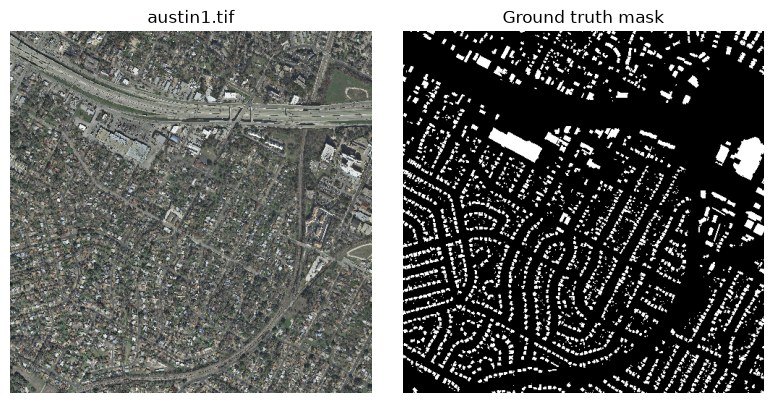

In [4]:
# Visual check: one image and its corresponding mask

example = image_files[0]
mask_file = example.replace("/images/", "/gt/")

with rasterio.open(example) as img, rasterio.open(mask_file) as mask:
    image_preview = img.read([1, 2, 3], out_shape=(3, 500, 500)).transpose(1, 2, 0)
    mask_preview = mask.read(1, out_shape=(500, 500))

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_preview)
plt.title(os.path.basename(example))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_preview, cmap="gray")
plt.title("Ground truth mask")
plt.axis("off")

plt.tight_layout()
plt.show()


## Task 2 — Split for the contest

All 5 labeled regions (Austin, Chicago, Kitsap, Tyrol-W, Vienna) go into training/validation now —
there's no reason to hold out a whole city, since the real contest test cities (Bellingham, Bloomington,
Innsbruck, San Francisco, Eastern Tyrol) are separate and unlabeled anyway. Val = first 5 tiles of
every region, matching Inria's own suggested split.

In [5]:
# Use tiles 1-5 from each region for validation
val_cutoff = 5

train_files = [f for f in image_files if city_and_number(f)[1] > val_cutoff]
val_files = [f for f in image_files if city_and_number(f)[1] <= val_cutoff]

all_files = train_files + val_files

assert len(all_files) == len(set(all_files))
assert set(all_files) == set(image_files)

print(f"Train: {len(train_files)} tiles")
print(f"Val: {len(val_files)} tiles")

Train: 155 tiles
Val: 25 tiles


## Task 3 — Reading patches without loading whole tiles

Same as before: `rasterio` windowed reads pull just the 512x512 window we need, random patches for
training, sliding window for full-tile prediction.

In [6]:
# Utilities for reading image patches

def tile_size(path):
    with rasterio.open(path) as src:
        return src.height, src.width


def read_patch(image_path, y, x, size=PATCH):
    # reads image + mask together — only works on the labeled train/ tiles
    window = rasterio.windows.Window(x, y, size, size)

    with rasterio.open(image_path) as src:
        image = src.read([1, 2, 3], window=window)

    mask_path = image_path.replace("/images/", "/gt/")
    with rasterio.open(mask_path) as src:
        mask = src.read(1, window=window)

    image = image.transpose(1, 2, 0)
    mask = (mask > 127).astype(np.uint8)

    return image, mask


def read_image_patch(image_path, y, x, size=PATCH):
    # same as read_patch but skips the mask lookup — the real test tiles have no /gt/ file
    window = rasterio.windows.Window(x, y, size, size)
    with rasterio.open(image_path) as src:
        image = src.read([1, 2, 3], window=window)
    return image.transpose(1, 2, 0)


class RandomPatchDataset(Dataset):
    # randomly samples patches during training, never loads a full tile into memory

    def __init__(self, files, patches_per_epoch):
        self.files = files
        self.n = patches_per_epoch
        self.sizes = {f: tile_size(f) for f in files}

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        path = random.choice(self.files)
        h, w = self.sizes[path]
        y = random.randint(0, h - PATCH)
        x = random.randint(0, w - PATCH)
        image, mask = read_patch(path, y, x)

        if random.random() < 0.5:
            image = image[:, ::-1]
            mask = mask[:, ::-1]
        if random.random() < 0.5:
            image = image[::-1, :]
            mask = mask[::-1, :]

        image = torch.from_numpy(np.ascontiguousarray(image.transpose(2, 0, 1))).float() / 255 - 0.5
        mask = torch.from_numpy(np.ascontiguousarray(mask)).float().unsqueeze(0)
        return image, mask


class FixedPatchDataset(Dataset):

    def __init__(self, files, limit=None):
        self.samples = []
        for path in files:
            h, w = tile_size(path)
            ys, xs = sliding_window_coords(h, w, size=PATCH, stride=PATCH)
            for y in ys:
                for x in xs:
                    self.samples.append((path, y, x))

        if limit is not None and len(self.samples) > limit:
            random.Random(SEED).shuffle(self.samples)
            self.samples = self.samples[:limit]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, y, x = self.samples[idx]
        image, mask = read_patch(path, y, x)
        image = torch.from_numpy(np.ascontiguousarray(image.transpose(2, 0, 1))).float() / 255 - 0.5
        mask = torch.from_numpy(np.ascontiguousarray(mask)).float().unsqueeze(0)
        return image, mask


def sliding_window_coords(h, w, size=PATCH, stride=None):
    # overlapping windows for full-tile prediction
    if stride is None:
        stride = size // 2
    ys = list(range(0, h - size + 1, stride)) + [h - size]
    xs = list(range(0, w - size + 1, stride)) + [w - size]
    return sorted(set(ys)), sorted(set(xs))


### 2.4 Model — U-Net with a ResNet34 encoder

In [7]:
def make_resnet34_encoder():
    try:
        model = torchvision.models.resnet34(weights=torchvision.models.ResNet34_Weights.IMAGENET1K_V1)
        return model, True
    except Exception:
        print("Pretrained weights unavailable. Using random initialization.")
        return torchvision.models.resnet34(weights=None), False


def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True)
    )


class UNetResNet34(nn.Module):
    def __init__(self):
        super().__init__()

        encoder, pretrained = make_resnet34_encoder()
        self.used_pretrained = pretrained

        self.stem = nn.Sequential(encoder.conv1, encoder.bn1, encoder.relu)
        self.pool = encoder.maxpool
        self.layer1 = encoder.layer1
        self.layer2 = encoder.layer2
        self.layer3 = encoder.layer3
        self.layer4 = encoder.layer4

        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = conv_block(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.up0 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.head = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        s0 = self.stem(x)
        s1 = self.layer1(self.pool(s0))
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)
        s4 = self.layer4(s3)

        d4 = self.dec4(torch.cat([self.up4(s4), s3], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s2], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s1], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s0], dim=1))

        return self.head(self.up0(d1))


model = UNetResNet34().to(device)

params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params:,}")
print(f"Using pretrained encoder: {model.used_pretrained}")

x = torch.randn(2, 3, PATCH, PATCH, device=device)
with torch.no_grad():
    out = model(x)
assert out.shape == (2, 1, PATCH, PATCH)
print("Output shape:", out.shape)


Parameters: 24,434,049
Using pretrained encoder: True
Output shape: torch.Size([2, 1, 512, 512])


### 2.5 Loss and metrics

In [8]:
def bce_dice_loss(logits, mask, edge_weight=4.0, k=5):
    # weighted BCE + Dice, extra weight near building edges
    with torch.no_grad():
        dilated = F.max_pool2d(mask, k, stride=1, padding=k // 2)
        eroded = -F.max_pool2d(-mask, k, stride=1, padding=k // 2)
        edge_map = dilated - eroded
        weight = 1 + edge_weight * edge_map

    bce = F.binary_cross_entropy_with_logits(logits, mask, reduction="none")
    bce = (bce * weight).mean()

    prob = torch.sigmoid(logits)
    dice = 1 - ((2 * (prob * mask).sum() + 1) / (prob.sum() + mask.sum() + 1))

    return bce + dice


def scores_from_counts(tp, fp, fn, tn):
    eps = 1e-9
    return {
        "IoU": tp / (tp + fp + fn + eps),
        "Dice/F1": 2 * tp / (2 * tp + fp + fn + eps),
        "precision": tp / (tp + fp + eps),
        "recall": tp / (tp + fn + eps),
        "pixel accuracy": (tp + tn) / (tp + fp + fn + tn + eps)
    }


# Check why pixel accuracy alone is not reliable for segmentation
sample_masks = np.stack([read_patch(f, 0, 0)[1] for f in train_files[:5]])
background_ratio = (sample_masks == 0).mean()

print(f"Predicting background everywhere would give {background_ratio:.1%} pixel accuracy but IoU = 0.")
print("Using IoU, Dice, precision, and recall for evaluation.")


Predicting background everywhere would give 82.8% pixel accuracy but IoU = 0.
Using IoU, Dice, precision, and recall for evaluation.


### 2.6 Training

In [9]:
train_ds = RandomPatchDataset(train_files, PATCHES_PER_EPOCH)
val_ds = FixedPatchDataset(val_files, limit=VAL_PATCHES if QUICK_RUN else None)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0)

print("Training patches:", len(train_ds))
print("Validation patches:", len(val_ds))

# Check one batch
images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)
print("Mask values:", torch.unique(masks))

Training patches: 4000
Validation patches: 2500
Images: torch.Size([8, 3, 512, 512])
Masks: torch.Size([8, 1, 512, 512])
Mask values: tensor([0., 1.])


In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

try:
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
except:
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

best_iou = -1.0
epochs_without_improvement = 0
PATIENCE = 10
history = []

print("Training setup ready")

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    model.train()
    total_loss = 0.0

    for image, mask in train_loader:
        image, mask = image.to(device), mask.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            loss = bce_dice_loss(model(image), mask)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * len(image)

    # Validation
    model.eval()
    tp = fp = fn = tn = 0

    with torch.no_grad():
        for image, mask in val_loader:
            image = image.to(device)

            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                pred = model(image) > 0

            pred, truth = pred.cpu(), mask > 0.5

            tp += int((pred & truth).sum())
            fp += int((pred & ~truth).sum())
            fn += int((~pred & truth).sum())
            tn += int((~pred & ~truth).sum())

    val_iou = scores_from_counts(tp, fp, fn, tn)["IoU"]
    scheduler.step(val_iou)

    epoch_time = time.time() - start
    train_loss = total_loss / len(train_ds)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_IoU": val_iou,
            "seconds": epoch_time,
        }
    )

    print(
        f"epoch {epoch:2d} | train loss {train_loss:.4f} | "
        f"validation IoU {val_iou:.3f} | {epoch_time:.0f}s"
    )

    if val_iou > best_iou:
        best_iou = val_iou
        epochs_without_improvement = 0
        torch.save(model.state_dict(), f"{OUT_DIR}/best_model.pth")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best validation IoU: {best_iou:.3f}")
        break

# Restore best model
model.load_state_dict(
    torch.load(f"{OUT_DIR}/best_model.pth", map_location=device)
)
model.eval()

history = pd.DataFrame(history)
history.to_csv(f"{OUT_DIR}/part2_training_history.csv", index=False)

print("Best IoU:", best_iou)

Training setup ready


epoch  1 | train loss 0.7928 | validation IoU 0.616 | 188s
epoch  2 | train loss 0.6609 | validation IoU 0.662 | 184s
epoch  3 | train loss 0.6258 | validation IoU 0.618 | 185s
epoch  4 | train loss 0.5983 | validation IoU 0.674 | 194s
epoch  5 | train loss 0.5827 | validation IoU 0.669 | 178s
epoch  6 | train loss 0.5806 | validation IoU 0.667 | 179s
epoch  7 | train loss 0.5592 | validation IoU 0.691 | 190s
epoch  8 | train loss 0.5409 | validation IoU 0.682 | 180s
epoch  9 | train loss 0.5459 | validation IoU 0.707 | 181s
epoch 10 | train loss 0.5200 | validation IoU 0.699 | 187s
epoch 11 | train loss 0.5160 | validation IoU 0.704 | 181s
epoch 12 | train loss 0.5061 | validation IoU 0.697 | 183s
epoch 13 | train loss 0.4806 | validation IoU 0.723 | 178s
epoch 14 | train loss 0.4761 | validation IoU 0.718 | 186s
epoch 15 | train loss 0.4835 | validation IoU 0.732 | 184s
epoch 16 | train loss 0.4723 | validation IoU 0.727 | 181s
epoch 17 | train loss 0.4618 | validation IoU 0.729 | 18

## Task 4 — Sanity-check on the validation split

There's no held-out labeled "test" city anymore — the real test set is the unlabeled contest tiles,
predicted on at the end. This is just a quick numeric check on the validation tiles (first 5 of each
region) to confirm the model trained properly before we bother running it on the real test tiles.

In [11]:
@torch.no_grad()
def predict_tile(image_path, batch_size=8):
    # sliding-window prediction on a labeled tile (uses read_patch, so needs a matching /gt/ file)
    with rasterio.open(image_path) as src:
        h, w = src.height, src.width

    ys, xs = sliding_window_coords(h, w)
    prob_sum = np.zeros((h, w), dtype=np.float32)
    count = np.zeros((h, w), dtype=np.float32)
    windows = [(y, x) for y in ys for x in xs]

    for start in range(0, len(windows), batch_size):
        batch = windows[start:start + batch_size]
        patches = np.stack([read_patch(image_path, y, x)[0] for y, x in batch])
        images = torch.from_numpy(patches.transpose(0, 3, 1, 2)).float().to(device) / 255 - 0.5

        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            preds = torch.sigmoid(model(images)).cpu().numpy()[:, 0]

        for (y, x), pred in zip(batch, preds):
            prob_sum[y:y+PATCH, x:x+PATCH] += pred
            count[y:y+PATCH, x:x+PATCH] += 1

    return (prob_sum / count) > 0.5


In [12]:
val_counts = {"tp": 0, "fp": 0, "fn": 0, "tn": 0}

for image_path in val_files:
    mask_path = image_path.replace("/images/", "/gt/")
    with rasterio.open(mask_path) as src:
        gt = src.read(1) > 127

    pred = predict_tile(image_path)

    val_counts["tp"] += int((pred & gt).sum())
    val_counts["fp"] += int((pred & ~gt).sum())
    val_counts["fn"] += int((~pred & gt).sum())
    val_counts["tn"] += int((~pred & ~gt).sum())

val_scores = scores_from_counts(**val_counts)

print(f"Validation set: {len(val_files)} tiles")
display(pd.DataFrame([val_scores]).round(3))

pd.DataFrame([val_scores]).round(4).to_csv(f"{OUT_DIR}/part2_val_results.csv", index=False)


Validation set: 25 tiles


,IoU,Dice/F1,precision,recall,pixel accuracy
0,0.754,0.86,0.858,0.861,0.961


## Contest submission — predicting on the real (unlabeled) test tiles

This is the part that actually matters for the contest. `read_patch()` always tries to open a `/gt/`
mask file, which would crash on the real test tiles since Inria doesn't release their labels.
`read_image_patch()` and `predict_tile_for_submission()` skip that and just predict, keeping each
tile's georeferencing so the saved TIFFs are valid GeoTIFFs.

In [13]:
@torch.no_grad()
def predict_tile_for_submission(image_path, batch_size=8):
    with rasterio.open(image_path) as src:
        h, w = src.height, src.width
        profile = src.profile

    ys, xs = sliding_window_coords(h, w)
    prob_sum = np.zeros((h, w), dtype=np.float32)
    count = np.zeros((h, w), dtype=np.float32)
    windows = [(y, x) for y in ys for x in xs]

    for start in range(0, len(windows), batch_size):
        batch = windows[start:start + batch_size]
        patches = np.stack([read_image_patch(image_path, y, x) for y, x in batch])
        images = torch.from_numpy(patches.transpose(0, 3, 1, 2)).float().to(device) / 255 - 0.5

        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            preds = torch.sigmoid(model(images)).cpu().numpy()[:, 0]

        for (y, x), pred in zip(batch, preds):
            prob_sum[y:y+PATCH, x:x+PATCH] += pred
            count[y:y+PATCH, x:x+PATCH] += 1

    mask = ((prob_sum / count) > 0.5).astype(np.uint8) * 255
    return mask, profile


In [14]:
test_files = sorted(glob.glob(f"{TEST_DATA_ROOT}/*.tif"))
print(f"{len(test_files)} test tiles found")

if len(test_files) == 0:
    raise FileNotFoundError("No test tiles found — download the official test set and point TEST_DATA_ROOT at it.")

os.makedirs("submission", exist_ok=True)

for i, path in enumerate(test_files, 1):
    mask, profile = predict_tile_for_submission(path)

    out_profile = profile.copy()
    out_profile.update(count=1, dtype="uint8")

    with rasterio.open(f"submission/{os.path.basename(path)}", "w", **out_profile) as dst:
        dst.write(mask, 1)

    if i % 10 == 0 or i == len(test_files):
        print(f"{i}/{len(test_files)} done")

print("All test tiles predicted, saved under submission/")


180 test tiles found
10/180 done
20/180 done
30/180 done
40/180 done
50/180 done
60/180 done
70/180 done
80/180 done
90/180 done
100/180 done
110/180 done
120/180 done
130/180 done
140/180 done
150/180 done
160/180 done
170/180 done
180/180 done
All test tiles predicted, saved under submission/


Run Inria's `compress.py` on the `submission/` folder before zipping if you want their compressed
format. Otherwise this is a plain zip of the raw TIFFs.

In [15]:
shutil.make_archive("submission", "zip", "submission")
print("Wrote submission.zip — upload this (or the compressed version) to the Inria submission page.")


Wrote submission.zip — upload this (or the compressed version) to the Inria submission page.


In [6]:
import shutil

compressed_dir = "submission_compressed"
os.makedirs(compressed_dir, exist_ok=True)

for file in os.listdir("submission"):
    if not file.endswith(".tif"):
        continue

    in_path = os.path.join("submission", file)
    out_path = os.path.join(compressed_dir, file)

    with rasterio.open(in_path) as src:
        data = src.read(1)
        profile = src.profile.copy()

    profile.update(
        compress="CCITTFAX4",
        nbits=1,
        dtype="uint8",
        count=1,
        tiled=False,
        blockysize=profile["height"],
    )

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(data, 1)

n_in = len([f for f in os.listdir("submission") if f.endswith(".tif")])
n_out = len([f for f in os.listdir(compressed_dir) if f.endswith(".tif")])
print(f"{n_out}/{n_in} tiles compressed")

shutil.make_archive("submission", "zip", compressed_dir)
print("Wrote submission.zip from the compressed tiles — upload this one.")

168/180 tiles compressed
Wrote submission.zip from the compressed tiles — upload this one.
